# Train LSTM PPO with Minimal Features (22 features)

**Goal:** Test if reducing features from 100 → 22 reduces overfitting

**Features:** Evidence-based minimal set from research (Jiang 2017, Zhang 2020)

**Data:** Weekly, normalized per-ticker with 52-week rolling z-score

## 1. Setup

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import config
from rl_system import create_walk_forward_folds, PortfolioEnv2

# Stable Baselines
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

print("✓ Imports complete")

✓ Loaded 22 features from metadata_minimal_weekly.json
  Using MINIMAL feature set (evidence-based)
✓ Imports complete


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Verify Configuration

In [2]:
print("=" * 80)
print("CONFIGURATION (MINIMAL FEATURES)")
print("=" * 80)

print(f"\nData:")
print(f"  Path: {config.DATA_PATH.name}")
print(f"  Features: {len(config.FEATURE_COLS)}")
print(f"  Using minimal features: {config.USE_MINIMAL_FEATURES}")

print(f"\nOutput:")
print(f"  Directory: {config.OUTPUT_DIR.name}")

print(f"\nTraining:")
print(f"  Total timesteps: {config.TOTAL_TIMESTEPS:,}")
print(f"  Early stopping patience: {config.EARLY_STOP_PATIENCE}")
print(f"  LSTM hidden size: {config.LSTM_HIDDEN_SIZE}")
print(f"  Learning rate: {config.LSTM_LEARNING_RATE}")

print(f"\nEnvironment (weekly):")
print(f"  Rebalance frequency: {config.REBALANCE_FREQUENCY} weeks")
print(f"  Transaction cost: {config.TRANSACTION_COST*100:.2f}%")
print(f"  Reward type: {config.REWARD_TYPE}")

# Show first few features
print(f"\nFeature sample (first 10 of {len(config.FEATURE_COLS)}):")
for i, feat in enumerate(config.FEATURE_COLS[:10], 1):
    print(f"  {i:2d}. {feat}")

CONFIGURATION (MINIMAL FEATURES)

Data:
  Path: train_minimal_features_weekly.parquet
  Features: 22
  Using minimal features: True

Output:
  Directory: models_minimal_features

Training:
  Total timesteps: 100,000
  Early stopping patience: 5
  LSTM hidden size: 75
  Learning rate: 0.0001

Environment (weekly):
  Rebalance frequency: 4 weeks
  Transaction cost: 0.25%
  Reward type: log_return

Feature sample (first 10 of 22):
   1. momentum_1w_norm
   2. momentum_4w_norm
   3. momentum_13w_norm
   4. returns_52w_norm
   5. volatility_4w_norm
   6. volatility_52w_norm
   7. price_to_sma_12w_norm
   8. price_to_ema_26w_norm
   9. macd_histogram_norm
  10. bb_position_norm


## 3. Load Training Data

In [3]:
print("Loading training data...")
train_data = pd.read_parquet(config.DATA_PATH)

print(f"\nData shape: {train_data.shape}")
print(f"Date range: {train_data['date'].min()} to {train_data['date'].max()}")
print(f"Tickers: {sorted(train_data['ticker'].unique())}")
print(f"Weeks of data: {train_data['date'].nunique()}")

# Check for NaN in features
nan_counts = train_data[config.FEATURE_COLS].isna().sum()
if nan_counts.sum() > 0:
    print(f"\n Warning: {nan_counts.sum()} total NaN values in features")
    print(f"Features with NaN:")
    for feat, count in nan_counts[nan_counts > 0].items():
        print(f"  - {feat}: {count}")
else:
    print("\n✓ No NaN values in features")

# Sample/feature ratio
n_samples = len(train_data)
n_features = len(config.FEATURE_COLS)
ratio = n_samples / n_features
print(f"\nSample/feature ratio: {ratio:.1f}")
if ratio >= 20:
    print("  ✓ EXCELLENT (>20 is ideal)")
elif ratio >= 10:
    print("  ✓ GOOD (10-20 is acceptable)")
else:
    print("  ⚠️ LOW (<10 has overfitting risk)")

Loading training data...

Data shape: (2989, 51)
Date range: 2015-06-25 00:00:00 to 2023-08-24 00:00:00
Tickers: ['AAPL', 'AMD', 'ASML', 'GOOG', 'MSFT', 'MU', 'NVDA']
Weeks of data: 427

✓ No NaN values in features

Sample/feature ratio: 135.9
  ✓ EXCELLENT (>20 is ideal)


## 4. Create Walk-Forward Folds

In [4]:
print("Creating walk-forward folds...")

# Create walk-forward folds with embargo gap
folds = create_walk_forward_folds(
    train_data=train_data,
    n_folds=config.N_FOLDS,
    min_train_size=None,  # Auto-calculate (max of 52 weeks or 20% of data)
    embargo_size=26,  # 6-month gap between train and val
    date_col='date'
)

print(f"\n✓ Created {len(folds)} folds")
for fold in folds:
    fold_idx = fold['fold_idx']
    train_fold = fold['train']
    val_fold = fold['val']
    train_dates = f"{train_fold['date'].min()} to {train_fold['date'].max()}"
    val_dates = f"{val_fold['date'].min()} to {val_fold['date'].max()}"
    print(f"\nFold {fold_idx}:")
    print(f"  Train: {len(train_fold):4d} samples | {train_dates}")
    print(f"  Val:   {len(val_fold):4d} samples | {val_dates}")
    print(f"  Embargo: {fold['embargo_periods']} weeks")

Creating walk-forward folds...

✓ Created 3 folds

Fold 0:
  Train:  595 samples | 2015-06-25 00:00:00 to 2017-02-02 00:00:00
  Val:    616 samples | 2017-08-10 00:00:00 to 2019-04-11 00:00:00
  Embargo: 26 weeks

Fold 1:
  Train: 1393 samples | 2015-06-25 00:00:00 to 2019-04-11 00:00:00
  Val:    616 samples | 2019-10-17 00:00:00 to 2021-06-17 00:00:00
  Embargo: 26 weeks

Fold 2:
  Train: 2191 samples | 2015-06-25 00:00:00 to 2021-06-17 00:00:00
  Val:    616 samples | 2021-12-23 00:00:00 to 2023-08-24 00:00:00
  Embargo: 26 weeks


## 5. Training Function

In [5]:
def train_lstm_ppo_fold(fold_idx, train_data, val_data):
    """
    Train LSTM PPO model on one fold.
    
    Uses evidence-based hyperparameters from Jiang (2017).
    Configuration: patience=5 (accepts SB3 bug, stops at 6 evals)
    LSTM=75 (compromise between capacity and regularization)
    """
    print(f"\n{'='*80}")
    print(f"TRAINING FOLD {fold_idx}")
    print(f"{'='*80}")
    
    # Create output directory for this fold
    fold_dir = config.OUTPUT_DIR / f'fold_{fold_idx}'
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    # Create environments
    print("\nCreating environments...")
    train_env = PortfolioEnv2(
        data=train_data,
        feature_cols=config.FEATURE_COLS,
        tickers=config.TICKERS,
        rebalance_frequency=config.REBALANCE_FREQUENCY,
        transaction_cost=config.TRANSACTION_COST,
        max_weight_per_asset=config.MAX_WEIGHT_PER_ASSET,
        reward_lookback=config.REWARD_LOOKBACK,
        initial_capital=config.INITIAL_CAPITAL,
        reward_type=config.REWARD_TYPE,
        date_col='date',
        seed=config.RANDOM_SEED
    )
    
    val_env = PortfolioEnv2(
        data=val_data,
        feature_cols=config.FEATURE_COLS,
        tickers=config.TICKERS,
        rebalance_frequency=config.REBALANCE_FREQUENCY,
        transaction_cost=config.TRANSACTION_COST,
        max_weight_per_asset=config.MAX_WEIGHT_PER_ASSET,
        reward_lookback=config.REWARD_LOOKBACK,
        initial_capital=config.INITIAL_CAPITAL,
        reward_type=config.REWARD_TYPE,
        date_col='date',
        seed=config.RANDOM_SEED
    )
    
    print(f"✓ Train env: {len(train_data)} samples")
    print(f"✓ Val env: {len(val_data)} samples")
    
    # Setup callbacks
    print("\nSetting up callbacks...")
    # OLD CONFIG: Use patience=5 (stops at 6 due to SB3 bug, but works better)
    stop_callback = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=5,  # Stops at 6 due to SB3 bug (old config)
        min_evals=3,
        verbose=1
    )
    
    eval_callback = EvalCallback(
        val_env,
        best_model_save_path=str(fold_dir),
        log_path=str(fold_dir),
        eval_freq=config.EVAL_FREQ,
        n_eval_episodes=config.N_EVAL_EPISODES,
        deterministic=True,
        callback_after_eval=stop_callback,
        verbose=0
    )
    
    # Create LSTM PPO model
    print("\nCreating LSTM PPO model...")
    print(f"  LSTM hidden size: {config.LSTM_HIDDEN_SIZE} (compromise: 50 < 75 < 100)")
    print(f"  Learning rate: {config.LSTM_LEARNING_RATE}")
    print(f"  Early stopping: patience=5 (stops at 6, old config)")
    print(f"  Min evals: 3 (warmup period)")
    
    model = RecurrentPPO(
        'MlpLstmPolicy',
        train_env,
        learning_rate=config.LSTM_LEARNING_RATE,
        n_steps=config.LSTM_N_STEPS,
        batch_size=config.LSTM_BATCH_SIZE,
        n_epochs=config.LSTM_N_EPOCHS,
        gamma=config.GAMMA,
        gae_lambda=config.GAE_LAMBDA,
        clip_range=config.CLIP_RANGE,
        ent_coef=config.LSTM_ENT_COEF,
        vf_coef=config.VF_COEF,
        max_grad_norm=config.MAX_GRAD_NORM,
        policy_kwargs=config.LSTM_POLICY_KWARGS,
        verbose=config.VERBOSE,
        tensorboard_log=str(fold_dir / 'tensorboard')
    )
    
    # Train
    print(f"\nTraining for {config.TOTAL_TIMESTEPS:,} timesteps...")
    model.learn(
        total_timesteps=config.TOTAL_TIMESTEPS,
        callback=eval_callback,
        progress_bar=True
    )
    
    print(f"\n✓ Fold {fold_idx} training complete")
    print(f"  Best model saved to: {fold_dir / 'best_model.zip'}")
    
    return model, fold_dir

print("✓ Training function defined")

✓ Training function defined


## 6. Train All Folds

In [6]:
# Train each fold
results = []

for fold in folds:
    fold_idx = fold['fold_idx']
    train_fold = fold['train']
    val_fold = fold['val']
    
    try:
        model, fold_dir = train_lstm_ppo_fold(fold_idx, train_fold, val_fold)
        results.append({
            'fold': fold_idx,
            'status': 'success',
            'fold_dir': fold_dir
        })
    except Exception as e:
        print(f"\n❌ Fold {fold_idx} failed: {e}")
        import traceback
        traceback.print_exc()
        results.append({
            'fold': fold_idx,
            'status': 'failed',
            'error': str(e)
        })

print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"Total folds: {len(results)}")
print(f"Successful: {sum(1 for r in results if r['status'] == 'success')}")
print(f"Failed: {sum(1 for r in results if r['status'] == 'failed')}")


TRAINING FOLD 0

Creating environments...
✓ Train env: 595 samples
✓ Val env: 616 samples

Setting up callbacks...

Creating LSTM PPO model...
  LSTM hidden size: 75 (compromise: 50 < 75 < 100)
  Learning rate: 0.0001
  Early stopping: patience=5 (stops at 6, old config)
  Min evals: 3 (warmup period)


Output()


Training for 100,000 timesteps...


Stopping training because there was no new best model in the last 6 evaluations

Output()

...

Stopping training because there was no new best model in the last 6 evaluations

Output()


✓ Fold 1 training complete
  Best model saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models_minimal_features/fold_1/best_model.zip

TRAINING FOLD 2

Creating environments...
✓ Train env: 2191 samples
✓ Val env: 616 samples

Setting up callbacks...

Creating LSTM PPO model...
  LSTM hidden size: 75 (compromise: 50 < 75 < 100)
  Learning rate: 0.0001
  Early stopping: patience=5 (stops at 6, old config)
  Min evals: 3 (warmup period)

Training for 100,000 timesteps...


Stopping training because there was no new best model in the last 6 evaluations


✓ Fold 2 training complete
  Best model saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models_minimal_features/fold_2/best_model.zip

TRAINING SUMMARY
Total folds: 3
Successful: 3
Failed: 0


## 7. Evaluation Results

In [7]:
# Load evaluation results from each fold
print("=" * 80)
print("EVALUATION RESULTS (MINIMAL FEATURES - 22 features)")
print("=" * 80)

for result in results:
    if result['status'] == 'success':
        fold_idx = result['fold']
        fold_dir = result['fold_dir']
        
        # Load evaluations.npz
        eval_file = fold_dir / 'evaluations.npz'
        if eval_file.exists():
            with np.load(eval_file) as data:
                timesteps = data['timesteps']
                results_array = data['results']
                ep_lengths = data['ep_lengths']
                
                # Calculate mean reward per evaluation
                mean_rewards = results_array.mean(axis=1)
                best_reward = mean_rewards.max()
                best_step = timesteps[mean_rewards.argmax()]
                final_reward = mean_rewards[-1]
                
                print(f"\nFold {fold_idx}:")
                print(f"  Best val reward: {best_reward:.4f} (at step {best_step:,})")
                print(f"  Final val reward: {final_reward:.4f}")
                print(f"  Evaluations: {len(timesteps)}")
                
                # Check for overfitting (significant drop from best to final)
                drop = (best_reward - final_reward) / abs(best_reward) * 100
                if drop > 10:
                    print(f"  ⚠️ Performance dropped {drop:.1f}% from peak (possible overfitting)")
                else:
                    print(f"  ✓ Stable performance (drop: {drop:.1f}%)")
        else:
            print(f"\nFold {fold_idx}: No evaluation file found")

EVALUATION RESULTS (MINIMAL FEATURES - 22 features)

Fold 0:
  Best val reward: 0.7841 (at step 7,500)
  Final val reward: 0.2768
  Evaluations: 9
  ⚠️ Performance dropped 64.7% from peak (possible overfitting)

Fold 1:
  Best val reward: 1.4087 (at step 2,500)
  Final val reward: 1.1930
  Evaluations: 9
  ⚠️ Performance dropped 15.3% from peak (possible overfitting)

Fold 2:
  Best val reward: 0.1867 (at step 20,000)
  Final val reward: 0.1185
  Evaluations: 14
  ⚠️ Performance dropped 36.5% from peak (possible overfitting)


## 8. Save Summary

In [8]:
# Save training summary
summary = {
    'feature_set': 'minimal_weekly',
    'n_features': len(config.FEATURE_COLS),
    'n_folds': len(results),
    'successful_folds': sum(1 for r in results if r['status'] == 'success'),
    'hyperparameters': {
        'lstm_hidden_size': config.LSTM_HIDDEN_SIZE,
        'learning_rate': config.LSTM_LEARNING_RATE,
        'early_stop_patience': config.EARLY_STOP_PATIENCE,
        'total_timesteps': config.TOTAL_TIMESTEPS
    },
    'features': config.FEATURE_COLS
}

summary_file = config.OUTPUT_DIR / 'training_summary_minimal_features.json'
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Saved training summary to: {summary_file}")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"\nNext steps:")
print(f"  1. Review evaluation results above")
print(f"  2. Compare to baseline (100 features) in models/ directory")
print(f"  3. Run backtests on test data")
print(f"  4. If results are good, this is your new baseline!")


✓ Saved training summary to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models_minimal_features/training_summary_minimal_features.json

TRAINING COMPLETE

Next steps:
  1. Review evaluation results above
  2. Compare to baseline (100 features) in models/ directory
  3. Run backtests on test data
  4. If results are good, this is your new baseline!


## 9. Backtest Trained Models

Evaluate trained LSTM PPO models on out-of-sample test data and compare with baseline strategies.

### 9.1 Setup Backtesting


In [9]:
from stable_baselines3.common.vec_env import DummyVecEnv
from rl_system import (
    PortfolioEnv, PortfolioMonitor,
    backtest_rl_agent, backtest_baseline,
    EqualWeight, BuyHold, RiskParity, Momentum, MinVariance
)
from feature_fixes_weekly import apply_minimal_feature_pipeline_weekly

# Setup output directory for backtest results
OUTPUT_DIR_BACKTEST = config.PROJECT_ROOT / 'results' / 'backtests_minimal_features'
OUTPUT_DIR_BACKTEST.mkdir(parents=True, exist_ok=True)

# Load test data (original with all features)
TEST_PATH = config.TEST_PATH_ORIGINAL  # Use original test data
test_data_raw = pd.read_parquet(TEST_PATH)
test_data_raw[config.DATE_COL] = pd.to_datetime(test_data_raw[config.DATE_COL])

# Load original feature columns from metadata
METADATA_ORIGINAL = config.PROJECT_ROOT / 'data' / 'processed' / 'metadata.json'
with open(METADATA_ORIGINAL, 'r') as f:
    metadata_original = json.load(f)
    original_feature_cols = metadata_original['feature_cols']

# Debug: Check if base features exist in test data
print("Checking base features in test data...")
base_features_needed = [f.replace('_norm', '') for f in config.FEATURE_COLS]
missing_base = [f for f in base_features_needed if f not in test_data_raw.columns]
if missing_base:
    print(f"WARNING: {len(missing_base)} base features missing from test data:")
    print(missing_base[:10])
    print(f"\nAvailable columns in test data ({len(test_data_raw.columns)}):")
    print(test_data_raw.columns.tolist()[:20])
else:
    print(f"✓ All {len(base_features_needed)} base features found in test data")

# Process test data to have minimal features (same as training data)
print("\nProcessing test data for minimal features...")
test_data, processed_feature_cols = apply_minimal_feature_pipeline_weekly(
    test_data_raw,
    original_feature_cols,
    ticker_col='ticker',
    normalize=True,
    norm_window=52,
    verbose=True
)

# Verify features match training features
print(f"\nProcessed test data features: {len(processed_feature_cols)}")
print(f"Training features: {len(config.FEATURE_COLS)}")

# Check if normalized features actually exist in the processed data
missing_norm = [f for f in config.FEATURE_COLS if f not in test_data.columns]
if missing_norm:
    print(f"\nERROR: {len(missing_norm)} normalized features missing from processed data:")
    print(missing_norm[:10])
    print("\nAvailable normalized features in processed data:")
    available_norm = [c for c in test_data.columns if c.endswith('_norm')]
    print(f"Found {len(available_norm)} normalized features")
    print(available_norm[:10])
    print("\nAll columns in processed test_data:")
    print(test_data.columns.tolist())
    raise ValueError(f"Missing {len(missing_norm)} required normalized features in test data")
else:
    print("✓ All normalized features present in test data")
    assert set(processed_feature_cols) == set(config.FEATURE_COLS), \
        "Test data features don't match training features!"
    print("✓ Test data features match training features")


Checking base features in test data...
✓ All 22 base features found in test data

Processing test data for minimal features...

EVIDENCE-BASED FEATURE ENGINEERING PIPELINE (WEEKLY DATA)
Input: 100 features
Target: ~20 features (literature standard)
Normalization: Per-ticker z-score (Zhang 2020)
Data frequency: WEEKLY
MINIMAL FEATURE SET SELECTION (WEEKLY DATA)
Target features (literature): 22
Available in data: 22
Missing: 0

Reducing from 100 → 22 features
Sample-to-feature ratio improvement:
  Before: 8.0 samples/feature
  After:  36.3 samples/feature
  Target: >10 samples/feature (preferably >20)
PER-TICKER Z-SCORE NORMALIZATION (WEEKLY DATA)
Method: Rolling z-score per ticker (Zhang et al. 2020)
Window: 52 weeks (~1.0 year)
Min periods: 26 weeks (~0.5 year)
Features to normalize: 22
Tickers: 7

Normalized features created: 22

Sample statistics for 'momentum_1w_norm':
  Mean: 0.0516 (should be ~0)
  Std:  1.1263 (should be ~1)
  Min:  -3.2409
  Max:  4.0807

PIPELINE COMPLETE
Final

In [10]:
# Verify test data
print(f"Test data shape: {test_data.shape}")
print(f"Date range: {test_data[config.DATE_COL].min().date()} to {test_data[config.DATE_COL].max().date()}")
print(f"Periods: {test_data[config.DATE_COL].nunique()}")
print(f"Tickers: {', '.join(config.TICKERS)}")
print(f"Features: {len(config.FEATURE_COLS)}")


Test data shape: (798, 51)
Date range: 2023-08-31 to 2025-10-30
Periods: 114
Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
Features: 22


### 9.2 Prepare Trained Models

Use models trained earlier in this notebook from the `results` list.


In [11]:
# Extract models from training results
# Models are stored in the 'results' list from the training section
trained_models = []

for result in results:
    if result['status'] == 'success':
        fold_idx = result['fold']
        fold_dir = result['fold_dir']
        
        # Load the best model from disk (saved during training)
        model_path = fold_dir / 'best_model.zip'
        if model_path.exists():
            try:
                model = RecurrentPPO.load(model_path)
                
                # Try to get validation metrics from logs if available
                val_sharpe = None
                val_log_path = fold_dir / 'logs' / 'val_evaluations.csv'
                if val_log_path.exists():
                    val_df = pd.read_csv(val_log_path)
                    val_sharpe = val_df['sharpe_ratio'].max() if 'sharpe_ratio' in val_df.columns else None
                
                trained_models.append({
                    'model': model,
                    'fold': fold_idx,
                    'val_sharpe': val_sharpe,
                    'model_path': str(model_path)
                })
                print(f"  Prepared fold {fold_idx} model for backtesting")
            except Exception as e:
                print(f"  Error loading fold {fold_idx}: {e}")
        else:
            print(f"  Warning: Model file not found for fold {fold_idx}")

print(f"\nPrepared {len(trained_models)} models for backtesting")


  Prepared fold 0 model for backtesting
  Prepared fold 1 model for backtesting
  Prepared fold 2 model for backtesting

Prepared 3 models for backtesting


### 9.3 Backtest RL Models


In [12]:
ppo_results = {}

for model_info in trained_models:
    fold_idx = model_info['fold']
    model_name = f"LSTM_PPO_fold{fold_idx}"
    
    print(f"Backtesting {model_name}...")
    
    try:
        result = backtest_rl_agent(
            model=model_info['model'],
            data=test_data,
            feature_cols=config.FEATURE_COLS,
            tickers=config.TICKERS,
            rebalance_frequency=config.REBALANCE_FREQUENCY,
            transaction_cost=config.TRANSACTION_COST,
            max_weight_per_asset=config.MAX_WEIGHT_PER_ASSET,
            reward_lookback=config.REWARD_LOOKBACK,
            initial_capital=config.INITIAL_CAPITAL,
            reward_type=config.REWARD_TYPE,
            seed=config.RANDOM_SEED,
            min_entropy=config.MIN_ENTROPY,
            max_turnover=config.MAX_TURNOVER,
            annualization_factor=config.ANNUALIZATION_FACTOR,
            risk_free_rate=config.RISK_FREE_RATE
        )
        
        result['model_type'] = 'LSTM_PPO'
        result['reward_type'] = config.REWARD_TYPE
        result['fold'] = fold_idx
        result['val_sharpe'] = model_info['val_sharpe']
        
        ppo_results[model_name] = result
        
        stats = result['stats']
        print(f"  Test Sharpe: {stats['sharpe_ratio']:.3f}")
        print(f"  Test Return: {stats['total_return']:.2%}")
        print(f"  Final Value: ${stats['portfolio_value']:,.2f}")
        
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
    
    print()


Backtesting LSTM_PPO_fold0...
  Test Sharpe: 1.078
  Test Return: 153.20%
  Final Value: $253,204.21

Backtesting LSTM_PPO_fold1...
  Test Sharpe: 0.724
  Test Return: 100.33%
  Final Value: $200,332.59

Backtesting LSTM_PPO_fold2...
  Test Sharpe: 1.418
  Test Return: 226.99%
  Final Value: $326,991.41



### 9.4 Backtest Baseline Strategies


In [13]:
baseline_strategies = {
    'Equal Weight': EqualWeight(config.TICKERS, config.MAX_WEIGHT_PER_ASSET),
    'Buy & Hold': BuyHold(config.TICKERS, config.MAX_WEIGHT_PER_ASSET),
    'Risk Parity': RiskParity(config.TICKERS, config.MAX_WEIGHT_PER_ASSET, config.DATE_COL, config.REWARD_LOOKBACK),
    'Momentum': Momentum(config.TICKERS, config.MAX_WEIGHT_PER_ASSET, config.DATE_COL, config.REWARD_LOOKBACK),
    'Min Variance': MinVariance(config.TICKERS, config.MAX_WEIGHT_PER_ASSET, config.DATE_COL, config.REWARD_LOOKBACK)
}

baseline_results = {}

for strategy_name, strategy in baseline_strategies.items():
    print(f"Backtesting {strategy_name}...")
    
    try:
        result = backtest_baseline(
            strategy=strategy,
            data=test_data,
            date_col=config.DATE_COL,
            tickers=config.TICKERS,
            rebalance_frequency=config.REBALANCE_FREQUENCY,
            transaction_cost=config.TRANSACTION_COST,
            initial_capital=config.INITIAL_CAPITAL,
            annualization_factor=config.ANNUALIZATION_FACTOR,
            risk_free_rate=config.RISK_FREE_RATE
        )
        
        result['model_type'] = 'Baseline'
        result['reward_type'] = 'N/A'
        
        baseline_results[strategy_name] = result
        
        stats = result['stats']
        print(f"  Sharpe: {stats['sharpe_ratio']:.3f} | Return: {stats['total_return']:.2%} | Value: ${stats['portfolio_value']:,.2f}")
        
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
    
    print()


Backtesting Equal Weight...
  Sharpe: 1.174 | Return: 121.27% | Value: $221,269.74

Backtesting Buy & Hold...
  Sharpe: 1.058 | Return: 115.90% | Value: $215,899.44

Backtesting Risk Parity...
  Sharpe: 1.133 | Return: 93.17% | Value: $193,174.92

Backtesting Momentum...
  Sharpe: 1.064 | Return: 120.71% | Value: $220,711.79

Backtesting Min Variance...
  Sharpe: 0.940 | Return: 79.43% | Value: $179,434.45



### 9.5 Combine Results and Calculate Metrics


In [14]:
all_results = {**ppo_results, **baseline_results}

summary = []

for name, result in all_results.items():
    stats = result['stats']
    traj = result['trajectory']
    
    # Calculate turnover
    if len(traj['weights']) > 1:
        weights_array = np.array(traj['weights'])
        turnovers = np.abs(np.diff(weights_array, axis=0)).sum(axis=1)
        avg_turnover = turnovers.mean()
        max_turnover = turnovers.max()
    else:
        avg_turnover = 0.0
        max_turnover = 0.0
    
    # Calculate win rate
    returns = np.array(traj['returns'])
    win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0.0
    
    # Calculate Calmar ratio
    calmar = abs(stats['total_return'] / stats['max_drawdown']) if stats['max_drawdown'] != 0 else 0.0
    
    # Calculate Sortino ratio
    downside_returns = returns[returns < 0]
    downside_std = np.std(downside_returns) if len(downside_returns) > 0 else 1e-8
    sortino = (np.mean(returns) / downside_std) * np.sqrt(config.ANNUALIZATION_FACTOR)
    
    summary.append({
        'Model': name,
        'Type': result.get('model_type', 'Unknown'),
        'Fold': result.get('fold', None),
        'Val Sharpe': result.get('val_sharpe', None),
        'Test Sharpe': stats['sharpe_ratio'],
        'Test Sortino': sortino,
        'Total Return': stats['total_return'],
        'Volatility': stats['volatility'],
        'Max Drawdown': stats['max_drawdown'],
        'Calmar Ratio': calmar,
        'Final Value': stats['portfolio_value'],
        'Avg Turnover': avg_turnover,
        'Win Rate': win_rate
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values('Test Sharpe', ascending=False).reset_index(drop=True)
summary_df['Rank'] = range(1, len(summary_df) + 1)

# Display results
print("Backtest Results Summary:")
print("=" * 100)
print(summary_df.to_string(index=False))


Backtest Results Summary:
         Model     Type  Fold Val Sharpe  Test Sharpe  Test Sortino  Total Return  Volatility  Max Drawdown  Calmar Ratio   Final Value  Avg Turnover  Win Rate  Rank
LSTM_PPO_fold2 LSTM_PPO   2.0       None     1.418402      3.008336      2.269914    0.356176     -0.294367      7.711162 326991.410155      0.114022  0.553571     1
  Equal Weight Baseline   NaN       None     1.173697      2.098416      1.212697    0.277310     -0.331003      3.663703 221269.739328      0.000000  0.584071     2
   Risk Parity Baseline   NaN       None     1.133233      2.111748      0.931749    0.232073     -0.289573      3.217671 193174.921486      0.035496  0.610619     3
LSTM_PPO_fold0 LSTM_PPO   0.0       None     1.077548      2.306784      1.532042    0.359628     -0.334660      4.577902 253204.214406      0.178084  0.553571     4
      Momentum Baseline   NaN       None     1.064227      1.992515      1.207118    0.304744     -0.364714      3.309763 220711.785955      0.1

### 9.6 Visualize Results


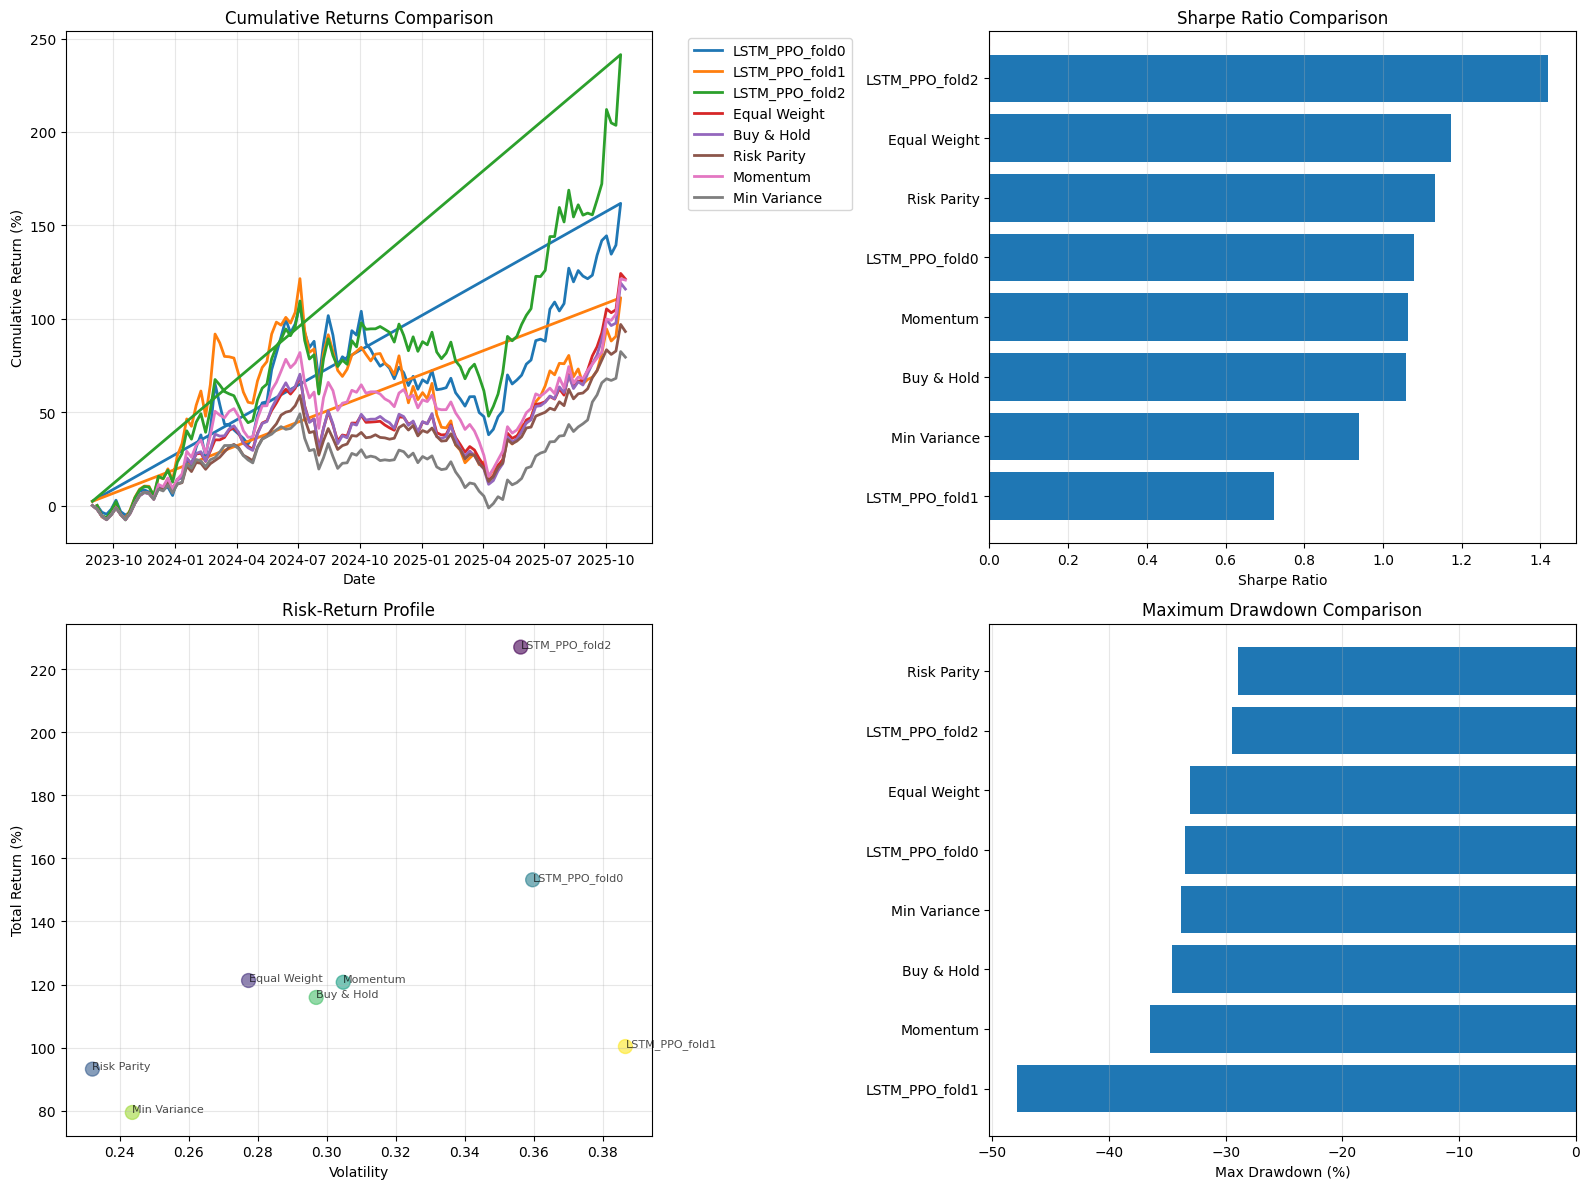

In [15]:
# Plot cumulative returns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cumulative Returns
ax = axes[0, 0]
for name, result in all_results.items():
    traj = result['trajectory']
    if len(traj['dates']) > 0 and len(traj['values']) > 0:
        dates = pd.to_datetime(traj['dates'])
        values = np.array(traj['values'])
        returns = (values / values[0] - 1) * 100
        ax.plot(dates, returns, label=name, linewidth=2)

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Cumulative Returns Comparison')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 2. Sharpe Ratio Comparison
ax = axes[0, 1]
sharpe_data = summary_df[['Model', 'Test Sharpe']].sort_values('Test Sharpe', ascending=True)
ax.barh(sharpe_data['Model'], sharpe_data['Test Sharpe'])
ax.set_xlabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio Comparison')
ax.axvline(x=0, color='r', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')

# 3. Risk-Return Scatter
ax = axes[1, 0]
ax.scatter(summary_df['Volatility'], summary_df['Total Return'] * 100, 
           s=100, alpha=0.6, c=range(len(summary_df)), cmap='viridis')
for idx, row in summary_df.iterrows():
    ax.annotate(row['Model'], (row['Volatility'], row['Total Return'] * 100), 
                fontsize=8, alpha=0.7)
ax.set_xlabel('Volatility')
ax.set_ylabel('Total Return (%)')
ax.set_title('Risk-Return Profile')
ax.grid(True, alpha=0.3)

# 4. Max Drawdown Comparison
ax = axes[1, 1]
drawdown_data = summary_df[['Model', 'Max Drawdown']].sort_values('Max Drawdown', ascending=True)
ax.barh(drawdown_data['Model'], drawdown_data['Max Drawdown'] * 100)
ax.set_xlabel('Max Drawdown (%)')
ax.set_title('Maximum Drawdown Comparison')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR_BACKTEST / 'backtest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.7 Save Results


In [16]:
# Save summary CSV
summary_df.to_csv(OUTPUT_DIR_BACKTEST / 'backtest_summary.csv', index=False)

# Save individual trajectories
for name, result in all_results.items():
    traj = result['trajectory']
    
    # Align arrays: returns may be shorter than dates/values (returns are between periods)
    dates = traj['dates']
    values = traj['values']
    returns = traj['returns']
    
    # Pad returns with NaN at the beginning if shorter (first period has no return)
    if len(returns) < len(dates):
        returns = [np.nan] * (len(dates) - len(returns)) + returns
    
    # Ensure all arrays have the same length
    min_len = min(len(dates), len(values), len(returns))
    dates = dates[:min_len]
    values = values[:min_len]
    returns = returns[:min_len]
    
    traj_df = pd.DataFrame({
        'date': dates,
        'portfolio_value': values,
        'return': returns
    })
    
    # Add weight columns
    if len(traj['weights']) > 0:
        weights_array = np.array(traj['weights'])
        # Align weights with dates (trim if needed)
        if len(weights_array) > min_len:
            weights_array = weights_array[:min_len]
        elif len(weights_array) < min_len:
            # Pad with last weight if shorter
            last_weight = weights_array[-1] if len(weights_array) > 0 else np.zeros(len(config.TICKERS))
            padding = np.tile(last_weight, (min_len - len(weights_array), 1))
            weights_array = np.vstack([weights_array, padding])
        
        weights_df = pd.DataFrame(weights_array, columns=config.TICKERS)
        traj_df = pd.concat([traj_df, weights_df], axis=1)
    1
    safe_name = name.lower().replace(' ', '_').replace('/', '_')
    traj_df.to_csv(OUTPUT_DIR_BACKTEST / f'trajectory_{safe_name}.csv', index=False)

print(f"Results saved to: {OUTPUT_DIR_BACKTEST}")
print(f"  - Summary: backtest_summary.csv")
print(f"  - Visualizations: backtest_comparison.png")
print(f"  - Trajectories: trajectory_*.csv")


Results saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests_minimal_features
  - Summary: backtest_summary.csv
  - Visualizations: backtest_comparison.png
  - Trajectories: trajectory_*.csv
